In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
data_path = r"C:\Users\Admin\Desktop\CollegeSem5\ML\assn8\UCI HAR Dataset"

X_train = pd.read_csv(
    data_path + r"\train\X_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    data_path + r"\test\X_test.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    data_path + r"\train\y_train.txt",
    header=None
)

y_test = pd.read_csv(
    data_path + r"\test\y_test.txt",
    header=None
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (7352, 561)
Test data shape: (2947, 561)
Training labels shape: (7352, 1)
Test labels shape: (2947, 1)


In [3]:
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True).values.ravel()

print("Complete dataset shape:", X.shape)
print("Labels shape:", y.shape)

Complete dataset shape: (10299, 561)
Labels shape: (10299,)


In [4]:
activity_labels = pd.read_csv(
    data_path + r"\activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["ID", "Activity"]
)

activity_labels

,ID,Activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [5]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (10299, 561)


In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA data shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

PCA data shape: (10299, 2)
Explained variance: 0.5697740681020986


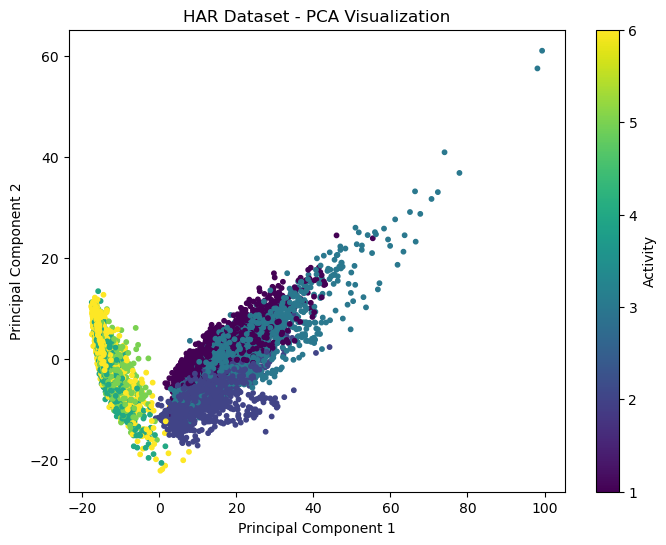

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("HAR Dataset - PCA Visualization")
plt.colorbar(label="Activity")
plt.show()

In [9]:
k_values = range(2, 9)

wcss = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

print("K-Means experiments completed.")

D:\random_driver\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\random_driver\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\random_driver\ANACONDA\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "D:\random_driver\ANACONDA\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

K-Means experiments completed.


In [10]:
kmeans_table = pd.DataFrame({
    "Number of Clusters (k)": list(k_values),
    "WCSS (Inertia)": wcss,
    "Silhouette Score": silhouette_scores
})

kmeans_table

,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,3.272857e+06,0.393732
1,3,2.921078e+06,0.315484
2,4,2.781602e+06,0.150005
3,5,2.654790e+06,0.128631
4,6,2.577180e+06,0.109895
5,7,2.519774e+06,0.081599
6,8,2.465379e+06,0.074867


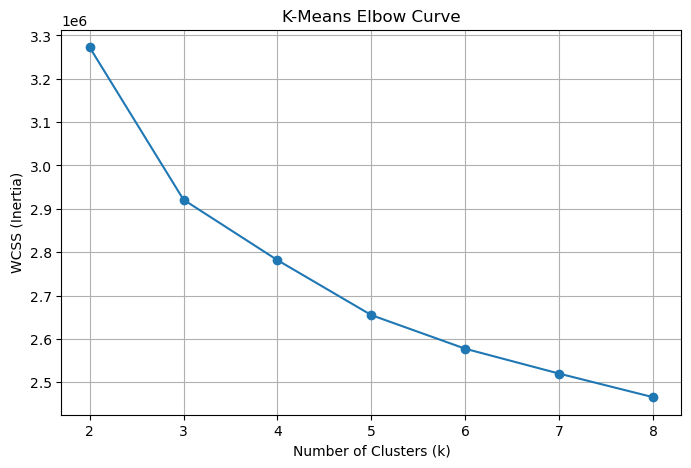

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, wcss, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("K-Means Elbow Curve")
plt.xticks(list(k_values))
plt.grid()
plt.show()

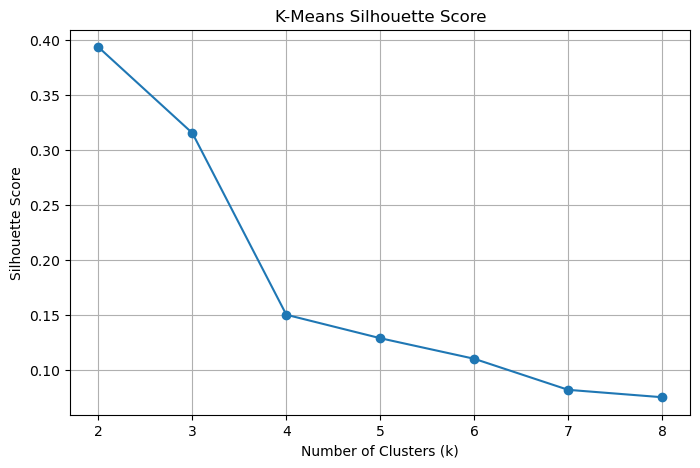

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.xticks(list(k_values))
plt.grid()
plt.show()

In [13]:
best_k = k_values[np.argmax(silhouette_scores)]

print("Best k based on Silhouette Score:", best_k)

Best k based on Silhouette Score: 2


In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")
print("Number of clusters:", len(np.unique(kmeans_labels)))

K-Means clustering completed.
Number of clusters: 2


In [15]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y, kmeans_labels)

kmeans_results = pd.DataFrame({
    "Algorithm": ["K-Means"],
    "Silhouette Score": [kmeans_silhouette],
    "Davies-Bouldin Index": [kmeans_db],
    "Calinski-Harabasz Index": [kmeans_ch],
    "ARI": [kmeans_ari],
    "NMI": [kmeans_nmi]
})

kmeans_results

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,ARI,NMI
0,K-Means,0.393732,1.070744,7880.813904,0.329611,0.545464


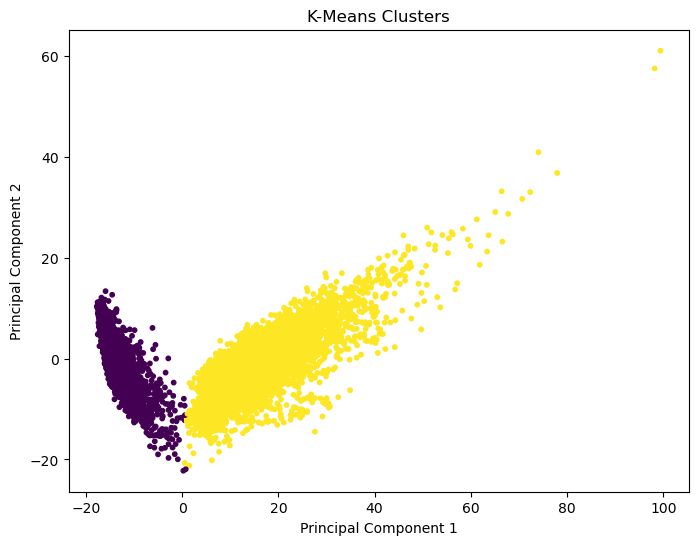

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.show()

In [17]:
dbscan = DBSCAN(eps=5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels = np.unique(dbscan_labels)

print("DBSCAN labels:", unique_labels)
print("Number of clusters:", len(unique_labels[unique_labels != -1]))
print("Number of noise points:", np.sum(dbscan_labels == -1))

DBSCAN labels: [-1]
Number of clusters: 0
Number of noise points: 10299


In [19]:
eps_values = [5, 10, 15, 20, 25]

dbscan_summary = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)

    dbscan_summary.append([eps, clusters, noise])

dbscan_summary = pd.DataFrame(
    dbscan_summary,
    columns=["Epsilon", "Number of Clusters", "Noise Points"]
)

dbscan_summary

,Epsilon,Number of Clusters,Noise Points
0,5,0,10299
1,10,25,7545
2,15,19,2029
3,20,1,434
4,25,2,127


In [20]:
valid_results = dbscan_summary[
    (dbscan_summary["Number of Clusters"] >= 2) &
    (dbscan_summary["Noise Points"] < len(X_scaled))
]

if len(valid_results) == 0:
    print("No suitable DBSCAN parameters found.")
else:
    best_eps = valid_results.iloc[0]["Epsilon"]

    dbscan = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    print("Selected epsilon:", best_eps)
    print("Clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
    print("Noise points:", np.sum(dbscan_labels == -1))

Selected epsilon: 10
Clusters: 25
Noise points: 7545


In [21]:
best_eps = 25

dbscan = DBSCAN(eps=best_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    X_scaled[dbscan_mask],
    dbscan_labels[dbscan_mask]
)

dbscan_db = davies_bouldin_score(
    X_scaled[dbscan_mask],
    dbscan_labels[dbscan_mask]
)

dbscan_ch = calinski_harabasz_score(
    X_scaled[dbscan_mask],
    dbscan_labels[dbscan_mask]
)

dbscan_ari = adjusted_rand_score(y, dbscan_labels)
dbscan_nmi = normalized_mutual_info_score(y, dbscan_labels)

print("DBSCAN Epsilon:", best_eps)
print("Clusters:", len(set(dbscan_labels)) - 1)
print("Noise points:", np.sum(dbscan_labels == -1))

DBSCAN Epsilon: 25
Clusters: 2
Noise points: 127


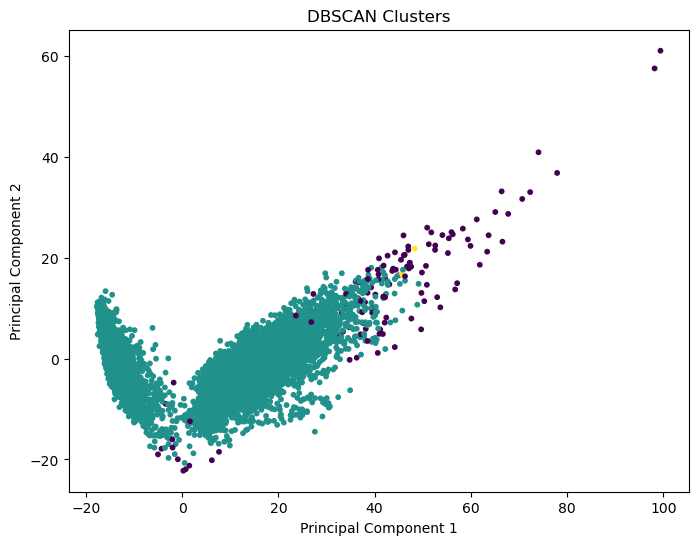

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters")
plt.show()

In [23]:
np.random.seed(42)

hac_indices = np.random.choice(
    len(X_scaled),
    size=3000,
    replace=False
)

X_hac = X_scaled[hac_indices]
y_hac = y[hac_indices]

print("HAC data shape:", X_hac.shape)

HAC data shape: (3000, 561)


In [24]:
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_hac)

print("Hierarchical clustering completed.")
print("Number of clusters:", len(np.unique(hierarchical_labels)))

Hierarchical clustering completed.
Number of clusters: 2


In [25]:
hier_silhouette = silhouette_score(X_hac, hierarchical_labels)
hier_db = davies_bouldin_score(X_hac, hierarchical_labels)
hier_ch = calinski_harabasz_score(X_hac, hierarchical_labels)
hier_ari = adjusted_rand_score(y_hac, hierarchical_labels)
hier_nmi = normalized_mutual_info_score(y_hac, hierarchical_labels)

print("Silhouette Score:", hier_silhouette)
print("Davies-Bouldin Index:", hier_db)
print("Calinski-Harabasz Index:", hier_ch)
print("ARI:", hier_ari)
print("NMI:", hier_nmi)

Silhouette Score: 0.39539113652728475
Davies-Bouldin Index: 1.0685297522429669
Calinski-Harabasz Index: 2312.1641322074342
ARI: 0.3323001107057674
NMI: 0.5548130600460166


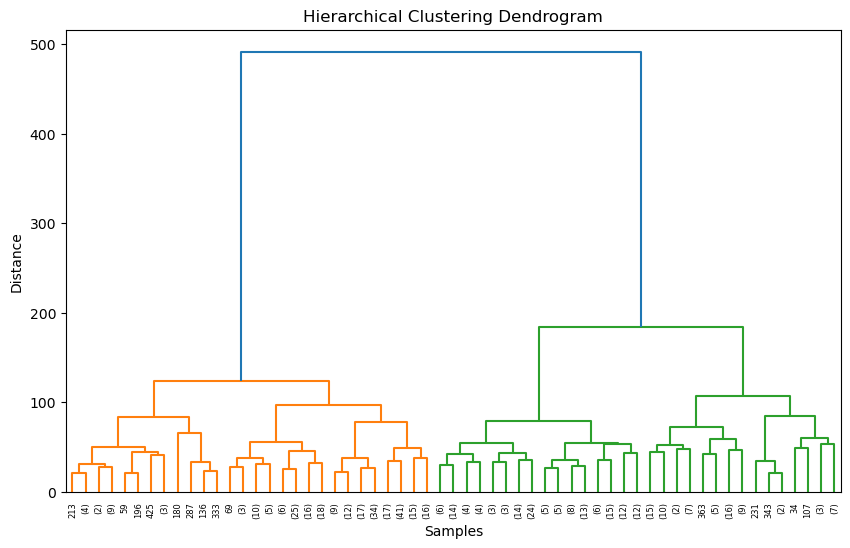

In [26]:
dendro_data = X_hac[:500]

linkage_matrix = linkage(
    dendro_data,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [27]:
results = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette,
        hier_silhouette
    ],
    "Davies-Bouldin Index": [
        kmeans_db,
        dbscan_db,
        hier_db
    ],
    "Calinski-Harabasz Index": [
        kmeans_ch,
        dbscan_ch,
        hier_ch
    ],
    "ARI": [
        kmeans_ari,
        dbscan_ari,
        hier_ari
    ],
    "NMI": [
        kmeans_nmi,
        dbscan_nmi,
        hier_nmi
    ]
})

results

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,ARI,NMI
0,K-Means,0.393732,1.070744,7880.813904,0.329611,0.545464
1,DBSCAN,0.484075,0.633715,18.870116,0.001583,0.014179
2,Hierarchical,0.395391,1.068530,2312.164132,0.332300,0.554813


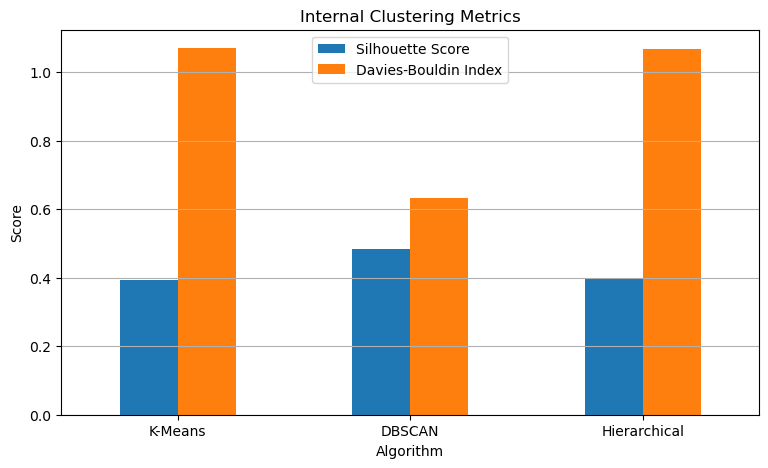

In [28]:
results.plot(
    x="Algorithm",
    y=[
        "Silhouette Score",
        "Davies-Bouldin Index"
    ],
    kind="bar",
    figsize=(9, 5)
)

plt.title("Internal Clustering Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

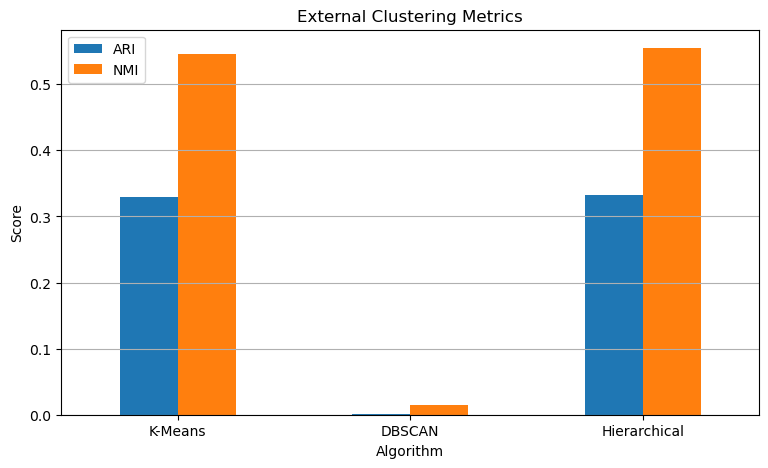

In [29]:
results.plot(
    x="Algorithm",
    y=["ARI", "NMI"],
    kind="bar",
    figsize=(9, 5)
)

plt.title("External Clustering Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [31]:
X_hac_pca = X_pca[hac_indices]

print("HAC PCA shape:", X_hac_pca.shape)

HAC PCA shape: (3000, 2)


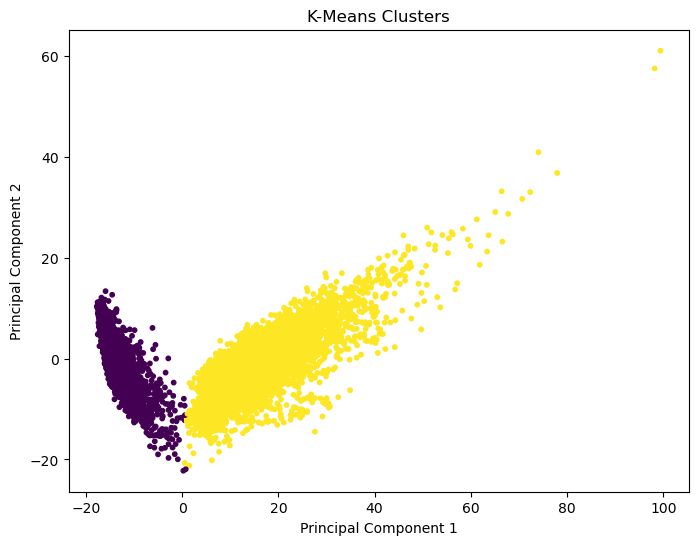

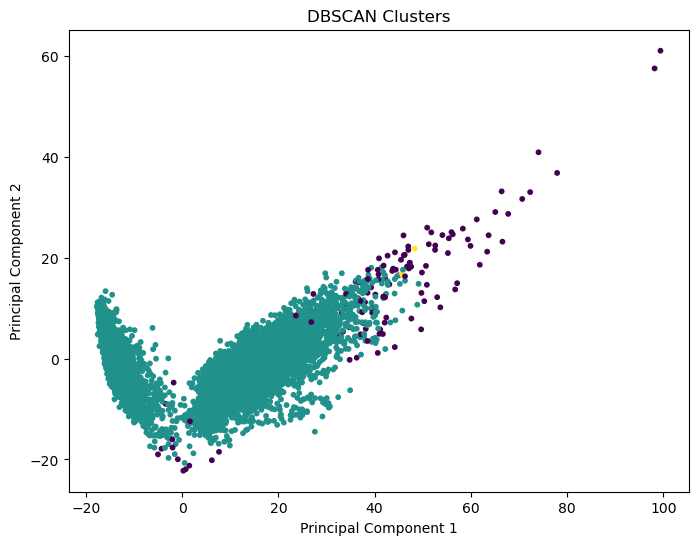

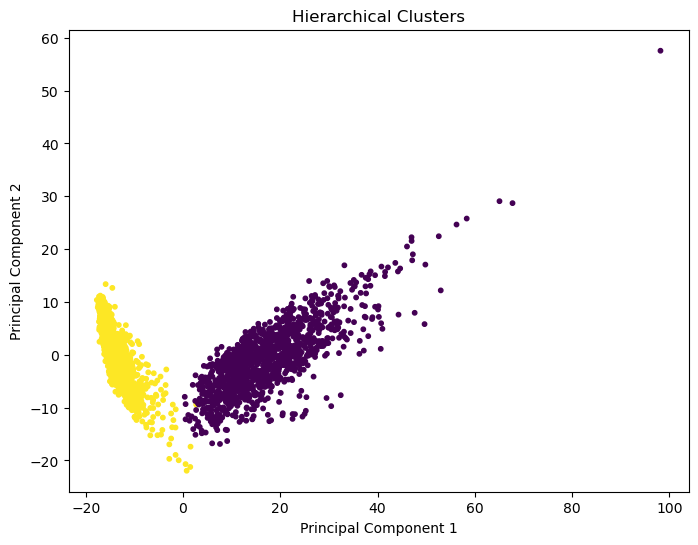

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters")
plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(
    X_hac_pca[:, 0],
    X_hac_pca[:, 1],
    c=hierarchical_labels,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters")
plt.show()